# 기하 배치 섭동(perturbation)과 경계 사례(Edge-case) 분석

### 8개 장애물 전체 접촉 그래프(contact graph)에서 feasibility robustness 측정

이 노트북은 앞선 프로젝트인
**「2차원 경로 계획의 형상 공간 연결성 분석」**에서 사용한
8개 장애물 배치와 접촉 충돌 규칙을 그대로 사용한다.

앞선 노트북에서는 고정된 장애물 배치에서 연속 공간의 이론적 임계반지름
$r_c$와 격자 A*가 관측한 임계값 $r_{c,h}$의 차이를 분석했다.
특히 좁은 통로와 격자점의 정렬로 발생하는 이산화 오차를 확인했다.

이번 노트북에서는 격자 A*를 반복하지 않고,
장애물 $C_3$의 위치에 작은 섭동을 적용했을 때
연속 공간의 임계반지름 $r_c$ 자체가 어떻게 변하는지를 분석한다.
이를 통해 격자 이산화 오차와 장애물 위치 불확실성의 영향을 분리한다.

- Workspace: $[0,12]\times[0,10]$
- 장애물: $A_1\sim A_4$, $C_1\sim C_4$, 반지름 0.5
- nominal 위치: $C_3=(8,3.8+\delta)$
- perturbation: $C_3'=(8,3.8+\delta+\varepsilon)$

각 perturbation sample마다 **8개 장애물 전체**로 contact graph를 다시 만들고,

$$
r_c=\min_{P:T\leadsto B}\max_{e\in P}\tau_e
$$

를 계산한다. 또한 global barrier가 A-chain인지 C-chain인지, C-chain 내부의 bottleneck edge가 무엇인지 기록한다.

> 접촉은 충돌이다. 따라서 $r<r_c$이면 통과 가능(feasible), $r\ge r_c$이면 통과 불가능(infeasible)이다.

In [1]:
from pathlib import Path
from dataclasses import dataclass
from heapq import heappush, heappop

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

L, H = 12.0, 10.0
EPS = 1e-10
SEED = 2026
N_SAMPLES = 200
NOISE = 0.02

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:.6f}")
print("Ready")

Ready


## 1. 기존 8-obstacle geometry 재사용

기존 노트북의 좌표를 그대로 쓴다.

| Chain A | 좌표 | Chain C | 좌표 |
|---|---:|---|---:|
| $A_1$ | $(4,7.9)$ | $C_1$ | $(8,8.5)$ |
| $A_2$ | $(4,5.3)$ | $C_2$ | $(8,6.2)$ |
| $A_3$ | $(4,2.7)$ | $C_3$ | $(8,3.8+\delta+\varepsilon)$ |
| $A_4$ | $(4,1.0)$ | $C_4$ | $(8,1.5)$ |

`epsilon=0`이면 기존과 완전히 같다.

In [2]:
@dataclass(frozen=True)
class Obstacle:
    name: str
    x: float
    y: float
    radius: float = 0.5

def make_obstacles(delta, epsilon=0.0):
    """Full 8-obstacle geometry; only C3 receives the perturbation epsilon."""
    obstacles = [
        Obstacle(f"A{i+1}", 4.0, y)
        for i, y in enumerate([7.9, 5.3, 2.7, 1.0])
    ] + [
        Obstacle("C1", 8.0, 8.5),
        Obstacle("C2", 8.0, 6.2),
        Obstacle("C3", 8.0, 3.8 + delta + epsilon),
        Obstacle("C4", 8.0, 1.5),
    ]

    for obs in obstacles:
        if not (obs.radius < obs.y < H - obs.radius):
            raise ValueError(
                f"{obs.name} leaves the valid workspace: "
                f"y={obs.y:.4f}, radius={obs.radius:.4f}"
            )
    return obstacles

display(pd.DataFrame([
    {"name": o.name, "x": o.x, "y": o.y, "radius": o.radius}
    for o in make_obstacles(delta=0.0)
]))

,name,x,y,radius
0,A1,4.000000,7.900000,0.500000
1,A2,4.000000,5.300000,0.500000
2,A3,4.000000,2.700000,0.500000
3,A4,4.000000,1.000000,0.500000
4,C1,8.000000,8.500000,0.500000
5,C2,8.000000,6.200000,0.500000
6,C3,8.000000,3.800000,0.500000
7,C4,8.000000,1.500000,0.500000


## 2. 접촉 그래프(Contact graph)와 최소 최대 장벽(minimax barrier)

기존 노트북과 같은 정의를 사용한다.

$$
\tau_{ij}
=\frac{\lVert c_i-c_j\rVert-R_i-R_j}{2},
\qquad
\tau_{iT}=\frac{H-y_i-R_i}{2},
\qquad
\tau_{iB}=\frac{y_i-R_i}{2}.
$$

Graph의 경로는 로봇 경로가 아니라, 위쪽과 아래쪽을 연결해 좌우 통과를 막는 **장애물 barrier**다.

In [3]:
def tau_ij(a, b):
    return (np.hypot(a.x - b.x, a.y - b.y) - a.radius - b.radius) / 2

def build_graph(obstacles):
    graph = {name: {} for name in ["T", "B"] + [o.name for o in obstacles]}

    def add(u, v, weight):
        graph[u][v] = graph[v][u] = max(0.0, float(weight))

    for i, a in enumerate(obstacles):
        add("T", a.name, (H - a.y - a.radius) / 2)
        add("B", a.name, (a.y - a.radius) / 2)
        for b in obstacles[i + 1:]:
            add(a.name, b.name, tau_ij(a, b))

    add("T", "B", H / 2)
    return graph

def active_connected(graph, r, start="T", goal="B"):
    """Contact is collision: edges with threshold <= r + EPS are active."""
    seen, stack = {start}, [start]

    while stack:
        u = stack.pop()
        if u == goal:
            return True

        for v, w in graph[u].items():
            if w <= r + EPS and v not in seen:
                seen.add(v)
                stack.append(v)

    return False

def minimax(graph, start="T", goal="B"):
    best = {v: float("inf") for v in graph}
    parent = {}
    best[start] = 0.0
    queue = [(0.0, start)]

    while queue:
        cost, u = heappop(queue)
        if cost > best[u]:
            continue

        if u == goal:
            path = [u]
            while path[-1] != start:
                path.append(parent[path[-1]])
            return float(cost), path[::-1]

        for v, weight in graph[u].items():
            candidate = max(cost, weight)
            if candidate < best[v]:
                best[v] = candidate
                parent[v] = u
                heappush(queue, (candidate, v))

    return float("inf"), []

def barrier_details(graph, path, rc, tol=1e-9):
    edge_rows = []
    bottlenecks = []

    for u, v in zip(path, path[1:]):
        w = graph[u][v]
        edge = f"{u}-{v}"
        edge_rows.append((edge, w))
        if abs(w - rc) <= tol:
            bottlenecks.append(edge)

    return edge_rows, bottlenecks

def evaluate_geometry(delta, epsilon=0.0, robot_r=None):
    obstacles = make_obstacles(delta, epsilon)
    graph = build_graph(obstacles)
    rc, path = minimax(graph)
    edge_rows, bottlenecks = barrier_details(graph, path, rc)

    result = {
        "delta": float(delta),
        "epsilon": float(epsilon),
        "effective_delta": float(delta + epsilon),
        "rc": rc,
        "path": path,
        "path_text": " → ".join(path),
        "bottleneck_edges": ", ".join(bottlenecks),
        "edge_rows": edge_rows,
        "graph": graph,
        "obstacles": obstacles,
    }

    if robot_r is not None:
        result["feasible"] = not active_connected(graph, robot_r)
    return result

## 3. 기존 이론식과 전체 graph의 일치 재검증

기존 환경의 closed form은

$$
r_c(d)=
\min\left(
0.8,\,
\max\left(0.7-\frac d2,\,0.65+\frac d2\right)
\right).
$$

위 식에서 섭동 후 유효 위치 변수는

$$
d=\delta+\varepsilon
$$

이다.

기존 노트북의 명목 분석 범위는 $\delta\in[-0.4,0.5]$였지만,
이번 실험에서 $\delta=-0.4$에
$\varepsilon\in[-0.02,0.02]$를 적용하면
유효 변수 $d$는 최저 $-0.42$까지 내려간다.

따라서 기존 식을 단순히 분석 범위 밖으로 외삽한다고 가정하지 않고,
각 섭동 표본에서 전체 8개 장애물의 접촉 그래프를 다시 구성하여
최소 최대 임계값을 계산한다.
그 결과와 닫힌형 이론식이 일치하는지도 표본마다 독립적으로 확인한다.

In [4]:
def rc_formula(effective_delta):
    d = np.asarray(effective_delta)
    return np.minimum(0.8, np.maximum(0.7 - d / 2, 0.65 + d / 2))

validation_deltas = np.linspace(-0.4, 0.5, 181)
graph_values = np.array([
    evaluate_geometry(d)["rc"] for d in validation_deltas
])
formula_values = rc_formula(validation_deltas)

np.testing.assert_allclose(graph_values, formula_values, atol=1e-12)

validation_rows = []
for delta in [-0.40, -0.10, 0.05, 0.30]:
    out = evaluate_geometry(delta)
    validation_rows.append({
        "delta": delta,
        "graph_rc": out["rc"],
        "formula_rc": float(rc_formula(delta)),
        "barrier": out["path_text"],
        "bottleneck_edges": out["bottleneck_edges"],
    })

display(pd.DataFrame(validation_rows))
print("PASS: original 8-obstacle graph and closed form agree on 181 layouts.")

,delta,graph_rc,formula_rc,barrier,bottleneck_edges
0,-0.400000,0.800000,0.800000,T → A1 → A2 → A3 → A4 → B,"T-A1, A1-A2, A2-A3"
1,-0.100000,0.750000,0.750000,T → C1 → C2 → C3 → C4 → B,C2-C3
2,0.050000,0.675000,0.675000,T → C1 → C2 → C3 → C4 → B,"C2-C3, C3-C4"
3,0.300000,0.800000,0.800000,T → C1 → C2 → C3 → C4 → B,C3-C4


PASS: original 8-obstacle graph and closed form agree on 181 layouts.


## 4. Monte Carlo perturbation

각 sample에서

$$
\varepsilon\sim\operatorname{Uniform}(-0.02,0.02)
$$

를 뽑는다. 매번 8개 장애물 전체 graph를 다시 계산하고 다음을 기록한다.

- perturbed $r_c$
- feasible / infeasible
- nominal 판정과 달라졌는지
- 선택된 minimax barrier
- barrier의 bottleneck edge

In [5]:
def sample_epsilon(rng, n, distribution="uniform", noise=NOISE):
    if distribution == "uniform":
        return rng.uniform(-noise, noise, size=n)
    if distribution == "normal":
        return rng.normal(0.0, noise, size=n)
    raise ValueError("distribution must be 'uniform' or 'normal'")

def run_perturbation(
    delta,
    robot_r,
    n=N_SAMPLES,
    distribution="uniform",
    noise=NOISE,
    seed=SEED,
):
    if robot_r < 0:
        raise ValueError("robot_r must be nonnegative")
    if n <= 0:
        raise ValueError("n must be positive")
    if noise < 0:
        raise ValueError("noise must be nonnegative")

    nominal = evaluate_geometry(delta, epsilon=0.0, robot_r=robot_r)
    nominal_rc = nominal["rc"]
    nominal_feasible = nominal["feasible"]
    nominal_margin = nominal_rc - robot_r
    if abs(nominal_margin) < EPS:
        nominal_margin = 0.0

    rng = np.random.default_rng(seed)
    eps_samples = sample_epsilon(rng, n, distribution, noise)

    rows = []
    for eps in eps_samples:
        out = evaluate_geometry(delta, epsilon=float(eps), robot_r=robot_r)

        # Independent check against the closed form for the perturbed layout.
        np.testing.assert_allclose(
            out["rc"], rc_formula(out["effective_delta"]), atol=1e-12
        )

        rows.append({
            "delta": float(delta),
            "epsilon": float(eps),
            "effective_delta": out["effective_delta"],
            "robot_r": float(robot_r),
            "nominal_rc": nominal_rc,
            "rc": out["rc"],
            "rc_shift": out["rc"] - nominal_rc,
            "nominal_margin": nominal_margin,
            "perturbed_margin": out["rc"] - robot_r,
            "nominal_feasible": nominal_feasible,
            "feasible": out["feasible"],
            "flipped": out["feasible"] != nominal_feasible,
            "barrier": out["path_text"],
            "bottleneck_edges": out["bottleneck_edges"],
        })

    return pd.DataFrame(rows)

def summarize_experiment(label, df):
    return {
        "case": label,
        "delta": df["delta"].iloc[0],
        "robot_r": df["robot_r"].iloc[0],
        "nominal_rc": df["nominal_rc"].iloc[0],
        "nominal_margin": df["nominal_margin"].iloc[0],
        "nominal_status": (
            "feasible" if df["nominal_feasible"].iloc[0] else "infeasible"
        ),
        "mean_rc": df["rc"].mean(),
        "std_rc": df["rc"].std(ddof=1),
        "min_rc": df["rc"].min(),
        "max_rc": df["rc"].max(),
        "flip_rate": df["flipped"].mean(),
    }

## 5. 세 가지 핵심 case

### 안정적인 평탄 구간(Stable plateau)

$\delta=-0.4$에서는 C-chain을 흔들어도 A-chain의 threshold $0.8$이 global $r_c$를 결정한다.

### 선형 구간의 임계곙계 근처

$\delta=-0.1$에서는 C2–C3 edge가 bottleneck이다. Nominal margin을 0.005로 두어 작은 perturbation이 판정을 뒤집을 수 있게 한다.

### V자 꼭짓점(V-cusp)의 정확한 임계 경계

$\delta=0.05$에서는 C2–C3와 C3–C4가 동시에 bottleneck이다. $C_3$를 어느 방향으로 움직여도 한쪽 간격은 좁아지지만 반대쪽 간격은 넓어진다. 장애물 사슬이 완성되려면 모든 간격이 닫혀야 하므로, 넓어진 쪽 간선의 접촉 임계값이 새로운 병목이 되어 $r_c$가 증가한다. 이는 일반적인 선형 branch의 exact-boundary case와 다른 중요한 edge case다.

In [6]:
SCENARIOS = [
    {"label": "Stable plateau", "delta": -0.40, "robot_r": 0.600},
    {"label": "Near boundary",  "delta": -0.10, "robot_r": 0.745},
    {"label": "Exact V-cusp",   "delta":  0.05, "robot_r": 0.675},
]

results = {}
summary_rows = []

for i, scenario in enumerate(SCENARIOS):
    label = scenario["label"]
    df = run_perturbation(
        delta=scenario["delta"],
        robot_r=scenario["robot_r"],
        n=N_SAMPLES,
        distribution="uniform",
        noise=NOISE,
        seed=SEED + i,
    )
    results[label] = df
    summary_rows.append(summarize_experiment(label, df))

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

print("Flip-rate summary")
for _, row in summary_df.iterrows():
    print(
        f"- {row['case']}: margin={row['nominal_margin']:.4f}, "
        f"flip rate={100 * row['flip_rate']:.1f}%"
    )

,case,delta,robot_r,nominal_rc,nominal_margin,nominal_status,mean_rc,std_rc,min_rc,max_rc,flip_rate
0,Stable plateau,-0.400000,0.600000,0.800000,0.200000,feasible,0.800000,0.000000,0.800000,0.800000,0.000000
1,Near boundary,-0.100000,0.745000,0.750000,0.005000,feasible,0.750231,0.005937,0.740173,0.759840,0.220000
2,Exact V-cusp,0.050000,0.675000,0.675000,0.000000,infeasible,0.680172,0.002869,0.675006,0.684928,1.000000


Flip-rate summary
- Stable plateau: margin=0.2000, flip rate=0.0%
- Near boundary: margin=0.0050, flip rate=22.0%
- Exact V-cusp: margin=0.0000, flip rate=100.0%


## 6. $r_c$ histogram

- 검은 점선: nominal $r_c$
- 빨간 실선: robot radius $r$
- histogram: perturbed $r_c$ 분포

Stable plateau에서는 $r_c$가 움직이지 않는 것이 정상이다. Exact V-cusp에서는 분포가 nominal minimum의 오른쪽에만 생긴다.

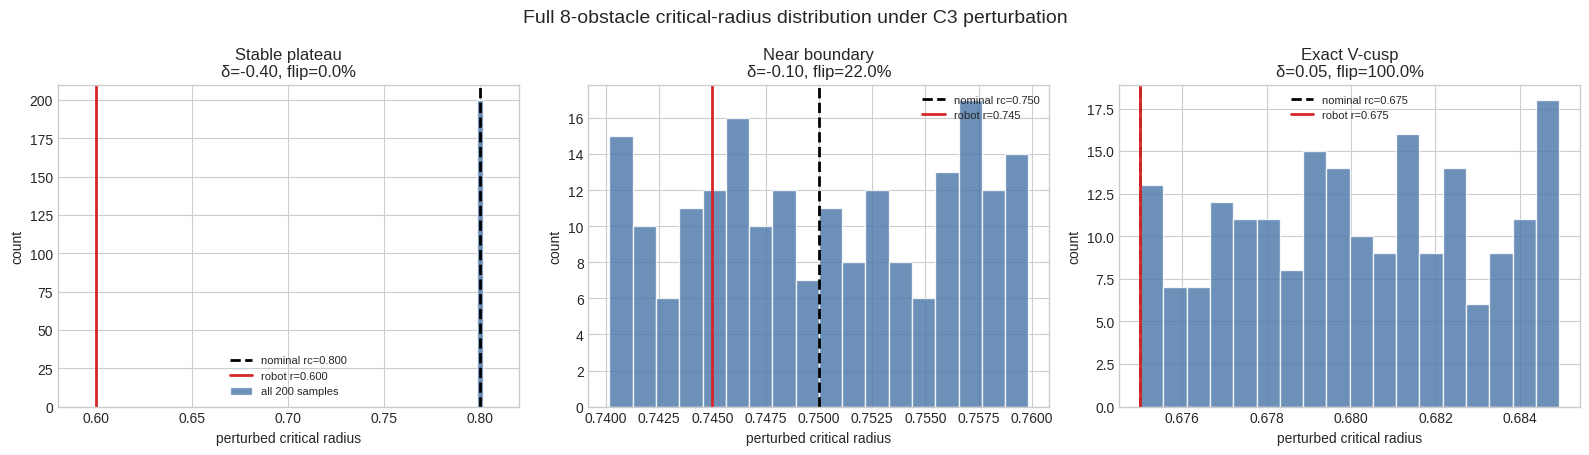

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), sharey=False)

for ax, scenario in zip(axes, SCENARIOS):
    label = scenario["label"]
    df = results[label]

    rc0 = df["nominal_rc"].iloc[0]
    robot_r = df["robot_r"].iloc[0]
    flip_rate = df["flipped"].mean()
    unique_rc = df["rc"].nunique()

    if unique_rc == 1:
        # 모든 sample의 rc가 같은 경우:
        # 넓은 histogram 막대 대신 rc 위치에 좁은 막대 하나를 표시한다.
        ax.bar(
            [rc0],
            [len(df)],
            width=0.003,
            color="#4C78A8",
            alpha=0.82,
            edgecolor="white",
            label=f"all {len(df)} samples",
        )

        # robot_r=0.6과 rc=0.8이 모두 보이도록 범위를 설정한다.
        x_left = min(robot_r, rc0) - 0.02
        x_right = max(robot_r, rc0) + 0.02
        ax.set_xlim(x_left, x_right)

    else:
        ax.hist(
            df["rc"],
            bins=18,
            color="#4C78A8",
            alpha=0.82,
            edgecolor="white",
        )

    ax.axvline(
        rc0,
        color="black",
        linestyle="--",
        linewidth=2,
        label=f"nominal rc={rc0:.3f}",
    )

    ax.axvline(
        robot_r,
        color="#D62728",
        linewidth=2,
        label=f"robot r={robot_r:.3f}",
    )

    ax.set_title(
        f"{label}\n"
        f"δ={scenario['delta']:.2f}, "
        f"flip={100 * flip_rate:.1f}%"
    )

    ax.set_xlabel("perturbed critical radius")
    ax.set_ylabel("count")
    ax.legend(fontsize=8)

fig.suptitle(
    "Full 8-obstacle critical-radius distribution under C3 perturbation",
    fontsize=14,
)

plt.tight_layout()
plt.show()

## 7. 장벽(Barrier)과 병목(bottleneck) 간선의 전환

단순히 $r_c$ 값만 보는 것보다, 어떤 chain과 어떤 edge가 global threshold를 결정했는지 함께 보면 geometry 변화의 원인을 설명할 수 있다.

In [8]:
barrier_tables = []

for label, df in results.items():
    counts = (
        df.groupby(["barrier", "bottleneck_edges"])
        .size()
        .reset_index(name="count")
    )
    counts["case"] = label
    counts["rate"] = counts["count"] / len(df)
    barrier_tables.append(counts)

barrier_df = pd.concat(barrier_tables, ignore_index=True)
display(
    barrier_df[
        ["case", "barrier", "bottleneck_edges", "count", "rate"]
    ].sort_values(["case", "count"], ascending=[True, False])
)

,case,barrier,bottleneck_edges,count,rate
2,Exact V-cusp,T → C1 → C2 → C3 → C4 → B,C2-C3,104,0.520000
3,Exact V-cusp,T → C1 → C2 → C3 → C4 → B,C3-C4,96,0.480000
1,Near boundary,T → C1 → C2 → C3 → C4 → B,C2-C3,200,1.000000
0,Stable plateau,T → A1 → A2 → A3 → A4 → B,"T-A1, A1-A2, A2-A3",200,1.000000


## 8. 부호 있는 여유(Signed margin)와 판정 전환율(flip rate)

$$
m=r_c^{\mathrm{nominal}}-r
$$

- $m>0$: nominally feasible
- $m=0$: nominal boundary
- $m<0$: nominally infeasible

Stable plateau, linear branch, V-cusp에서 sensitivity curve의 형태가 서로 다르게 나타나는지 확인한다.

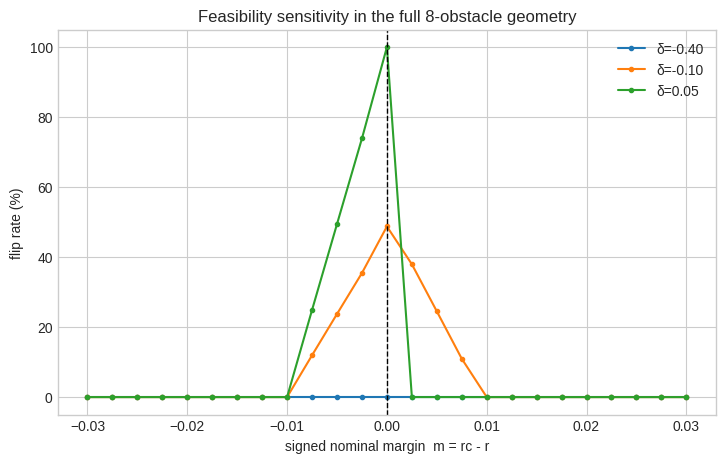

,delta,margin,robot_r,flip_rate
0,-0.400000,-0.030000,0.830000,0.000000
1,-0.100000,0.000000,0.750000,0.487500
2,0.050000,0.000000,0.675000,1.000000


In [9]:
def margin_sensitivity_curve(
    delta,
    margins=np.linspace(-0.03, 0.03, 25),
    n=2000,
    noise=NOISE,
    seed=SEED,
):
    nominal = evaluate_geometry(delta)
    nominal_rc = nominal["rc"]

    rng = np.random.default_rng(seed)
    eps_samples = rng.uniform(-noise, noise, size=n)
    rc_samples = np.array([
        evaluate_geometry(delta, epsilon=float(eps))["rc"]
        for eps in eps_samples
    ])

    rows = []
    for margin in margins:
        robot_r = nominal_rc - margin
        nominal_feasible = not active_connected(nominal["graph"], robot_r)
        perturbed_feasible = robot_r < rc_samples - EPS
        flip_rate = np.mean(perturbed_feasible != nominal_feasible)

        rows.append({
            "delta": delta,
            "margin": margin,
            "robot_r": robot_r,
            "flip_rate": flip_rate,
        })

    return pd.DataFrame(rows)

curve_df = pd.concat(
    [
        margin_sensitivity_curve(-0.40, seed=SEED),
        margin_sensitivity_curve(-0.10, seed=SEED + 1),
        margin_sensitivity_curve(0.05, seed=SEED + 2),
    ],
    ignore_index=True,
)

fig, ax = plt.subplots(figsize=(8.5, 5))

for delta, group in curve_df.groupby("delta"):
    ax.plot(
        group["margin"],
        100 * group["flip_rate"],
        marker="o",
        markersize=3,
        label=f"δ={delta:.2f}",
    )

ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("signed nominal margin  m = rc - r")
ax.set_ylabel("flip rate (%)")
ax.set_title("Feasibility sensitivity in the full 8-obstacle geometry")
ax.legend()
plt.show()

display(
    curve_df.loc[curve_df.groupby("delta")["flip_rate"].idxmax()]
    .sort_values("delta")
    .reset_index(drop=True)
)

## 9. 경계 사례(Edge-case) 검증

다음 성질을 자동으로 검사한다.

1. noise가 0이면 $r_c$와 판정이 변하지 않는다.
2. 같은 seed는 완전히 같은 결과를 만든다.
3. Stable plateau에서는 C3 perturbation에도 global $r_c=0.8$이다.
4. V-cusp에서는 $r_c\ge0.675$이며, perturbation 방향에 따라 bottleneck이 C2–C3 또는 C3–C4로 바뀐다.
5. $r=r_c$인 nominal geometry는 접촉 충돌 규칙에 따라 infeasible이다.

In [10]:
# 1) Zero noise
zero_noise = run_perturbation(
    delta=-0.10, robot_r=0.745, n=50, noise=0.0, seed=SEED
)
assert zero_noise["rc"].nunique() == 1
assert zero_noise["flipped"].mean() == 0.0

# 2) Reproducibility
rep_a = run_perturbation(-0.10, 0.745, n=30, seed=123)
rep_b = run_perturbation(-0.10, 0.745, n=30, seed=123)
pd.testing.assert_frame_equal(rep_a, rep_b)

# 3) Stable plateau controlled by A-chain
stable = results["Stable plateau"]
np.testing.assert_allclose(stable["rc"], 0.8, atol=1e-12)
assert stable["barrier"].str.contains("A1").all()

# 4) V-cusp and bottleneck switching
cusp = results["Exact V-cusp"]
assert (cusp["rc"] >= 0.675 - EPS).all()
assert set(cusp["bottleneck_edges"]).issubset({"C2-C3", "C3-C4"})
assert (cusp.loc[cusp["epsilon"] < 0, "bottleneck_edges"] == "C2-C3").all()
assert (cusp.loc[cusp["epsilon"] > 0, "bottleneck_edges"] == "C3-C4").all()

# 5) Exact contact is infeasible
nominal_cusp = evaluate_geometry(0.05, robot_r=0.675)
assert not nominal_cusp["feasible"]

print("PASS: all perturbation edge-case tests.")

PASS: all perturbation edge-case tests.


## 10. 선택 사항: 정규분포 위치 오차(noise)

균등분포 대신

$$
\varepsilon\sim N(0,\sigma^2)
$$

를 사용하려면 `distribution="normal"`로 바꾼다. 아래 예시는 선형 branch의 near-boundary case에 $\sigma=0.01$을 적용한다.

In [11]:
normal_df = run_perturbation(
    delta=-0.10,
    robot_r=0.745,
    n=N_SAMPLES,
    distribution="normal",
    noise=0.01,
    seed=SEED,
)

display(pd.DataFrame([
    summarize_experiment("Near boundary — normal noise", normal_df)
]))

,case,delta,robot_r,nominal_rc,nominal_margin,nominal_status,mean_rc,std_rc,min_rc,max_rc,flip_rate
0,Near boundary — normal noise,-0.100000,0.745000,0.750000,0.005000,feasible,0.749632,0.005471,0.734245,0.768737,0.190000


##11. 결과 해석과 앞선 실험과의 연결


1. **안정적인 평탄 구간(Stable plateau):** $\delta=-0.4$에서는 $C_3$에 위치 오차를 주어도 왼쪽 A-chain이 global barrier를 결정했다. 200개 표본 모두에서 $r_c=0.8$이 유지되었고, $r=0.6$에 대한 feasibility flip은 발생하지 않았다. 이는 일부 geometry가 변하더라도 다른 obstacle chain이 global threshold를 결정하고 있으면 전체 path feasibility는 영향을 받지 않을 수 있음을 보여준다.

2. **선형 구간(Linear branch):** $\delta=-0.1$에서는 C-chain이 global barrier를 형성하고, C2–C3 edge가 모든 표본에서 bottleneck으로 작용했다. Nominal 상태는 $r=0.745<r_c=0.75$로 feasible이지만 margin은 $0.005$에 불과했다.
이번에 사용한 고정 난수 시드의 균등분포 표본 200개에서는
$r_c$가 약 $0.7402$에서 $0.7598$까지 변했으며,
22%의 표본에서 통과 가능 판정이 통과 불가능으로 바뀌었다.
이 22%는 현재 표본에서 관측된 전환율이며,
분포 전체에 대한 정확한 이론 확률을 의미하지 않는다.
따라서 nominally feasible이더라도 위치 오차에 따른 최대 \(r_c\) 변화보다 margin이 작으면 robust한 feasible 상태라고 보기 어렵다.

3. **V자 꼭짓점(V-cusp):** $\delta=0.05$에서는 C2–C3와 C3–C4가 동시에 bottleneck이 되며 $r_c=0.675$의 최솟값을 만든다. $C_3$를 어느 방향으로 움직여도 두 gap 중 하나가 넓어지고, 그 edge가 새로운 bottleneck이 되어 $r_c$가 증가한다. 실제로 음의 perturbation에서는 C2–C3가 52%, 양의 perturbation에서는 C3–C4가 48%의 비율로 bottleneck이 되었다. Nominal 상태는 $r=r_c=0.675$이므로 접촉 충돌 규칙에 따라 infeasible이지만, 모든 비영 perturbation에서는 $r_c>0.675$가 되어 feasible로 바뀌었고 flip rate는 100%였다. 이는 일반적인 위험 사례라기보다 두 bottleneck이 교체되는 cusp의 특수한 민감도를 보여준다.

4. **명목 여유와 장벽 구조:** 실험 결과 feasibility sensitivity는 nominal margin만으로 결정되지 않았다. Stable plateau에서는 $C_3$가 global barrier에 포함되지 않아 margin 근처에서도 변화가 없었고, linear branch에서는 $r_c$가 perturbation에 선형으로 반응했다. V-cusp에서는 두 bottleneck이 교체되면서 방향에 관계없이 $r_c$가 증가했다. 따라서 robustness를 평가하려면 $r_c-r$뿐 아니라 global barrier와 bottleneck identity도 함께 확인해야 한다.



### 범위

이 실험은 contact graph를 이용한 continuous-space feasibility sensitivity 분석이다.
앞선 노트북인 **「2차원 경로 계획의 형상 공간 연결성 분석」**에서
연속 공간의 이론적 임계반지름 $r_c$와
격자 A*의 관측 임계값 $r_{c,h}$ 사이의 관계를 이미 검증했다.

따라서 이번 실험에서는 몬테카를로 표본마다 A*를 반복하지 않고,
전체 접촉 그래프에서 연속 공간 임계반지름 $r_c$를 다시 계산했다.
각 표본에 격자 A*까지 적용하면 장애물 위치 불확실성에 따른 변화와
격자 해상도·정렬에 따른 이산화 오차가 함께 섞이기 때문이다.
필요한 경우 대표 섭동 배치만 선택하여 A*로 별도 검증할 수 있다.


## 12. 결과 저장

실행 결과를 `results/perturbation/`에 저장한다.

- `summary.csv`: 사례별 핵심 수치
- `samples.csv`: 모든 몬테카를로 표본
- `barrier_frequency.csv`: 장벽·병목 간선의 빈도
- `margin_sensitivity.csv`: 명목 여유와 판정 전환율 데이터

In [12]:
OUT = Path("results/perturbation")
OUT.mkdir(parents=True, exist_ok=True)

all_samples_df = pd.concat(
    [df.assign(case=label) for label, df in results.items()],
    ignore_index=True,
)

summary_df.to_csv(OUT / "summary.csv", index=False)
all_samples_df.to_csv(OUT / "samples.csv", index=False)
barrier_df.to_csv(OUT / "barrier_frequency.csv", index=False)
curve_df.to_csv(OUT / "margin_sensitivity.csv", index=False)

print("Saved:")
for path in sorted(OUT.iterdir()):
    print("-", path)

Saved:
- results/perturbation/barrier_frequency.csv
- results/perturbation/margin_sensitivity.csv
- results/perturbation/samples.csv
- results/perturbation/summary.csv
